In [1]:
# 1. Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import mode

In [2]:
# 2. Load and preprocess images
image_size = (64, 64)
path = r"D:\projects\Disease-Detection-Project\datasets"  # Path to your dataset folder

data = []
labels = []

label_names = sorted(os.listdir(path))  # Sorted for consistent encoding
for label in label_names:
    folder_path = os.path.join(path, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, image_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        data.append(img.flatten())  # Convert to 1D feature vector
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

# 3. Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(f"Dataset loaded: {data.shape[0]} images, {len(label_names)} classes")
print(f"Classes: {label_names}")

Dataset loaded: 763 images, 4 classes
Classes: ['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_healthy']


Applying PCA for dimensionality reduction...
Shape after PCA: (763, 120)
Variance explained: 81.37%
Cluster labels shape: (763,)
KMeans Accuracy: 39.31847968545216


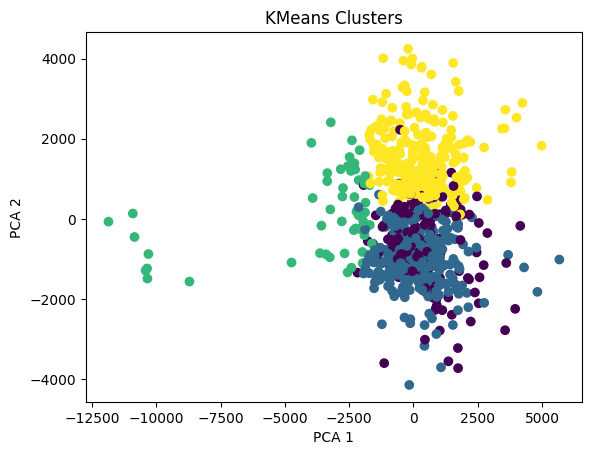

In [6]:
# 4. Reduce dimensions using PCA before K-Means
# Raw pixel data is too high-dimensional for K-Means to work well.
# PCA compresses it to 50 components while keeping most of the important info.
print("Applying PCA for dimensionality reduction...")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

data_pca = pca.fit_transform(data_scaled)

# PCA
pca = PCA(n_components=120, random_state=42)
data_pca = pca.fit_transform(data)

print(f"Shape after PCA: {data_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(data_pca)

print("Cluster labels shape:", clusters.shape)
import numpy as np
from scipy.stats import mode

cluster_labels = np.zeros_like(clusters)

for i in range(4):
    mask = (clusters == i)
    cluster_labels[mask] = mode(labels_encoded[mask], keepdims=True)[0]

from sklearn.metrics import accuracy_score

acc = accuracy_score(labels_encoded, cluster_labels)

print("KMeans Accuracy:", acc * 100)

import matplotlib.pyplot as plt

plt.scatter(data_pca[:,0], data_pca[:,1], c=clusters, cmap="viridis")
plt.title("KMeans Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [7]:
# 5. Apply K-Means Clustering
# Number of clusters = number of disease classes
n_clusters = len(label_names)

print(f"Running K-Means with {n_clusters} clusters...")
kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',   # Smarter initialization for better results
    n_init=10,          # Run 10 times with different seeds, pick best
    max_iter=300,
    random_state=42
)
cluster_labels = kmeans.fit_predict(data_pca)
print("K-Means clustering done!")

Running K-Means with 4 clusters...
K-Means clustering done!


In [8]:
# 6. Map each cluster to the most common true label in it
# Since K-Means doesn't know class names, we figure out which disease
# each cluster represents by majority vote.
cluster_to_label = {}
for cluster_id in range(n_clusters):
    mask = (cluster_labels == cluster_id)
    true_labels_in_cluster = labels_encoded[mask]
    most_common = mode(true_labels_in_cluster, keepdims=True).mode[0]
    cluster_to_label[cluster_id] = most_common

# Convert cluster assignments to predicted class labels
y_pred = np.array([cluster_to_label[c] for c in cluster_labels])

print("Cluster → Disease mapping:")
for cluster_id, label_id in cluster_to_label.items():
    print(f"  Cluster {cluster_id} → {le.inverse_transform([label_id])[0]}")

Cluster → Disease mapping:
  Cluster 0 → Tomato_Leaf_Mold
  Cluster 1 → Tomato_healthy
  Cluster 2 → Tomato_Late_blight
  Cluster 3 → Tomato_Leaf_Mold


K-Means Clustering Accuracy: 38.01%


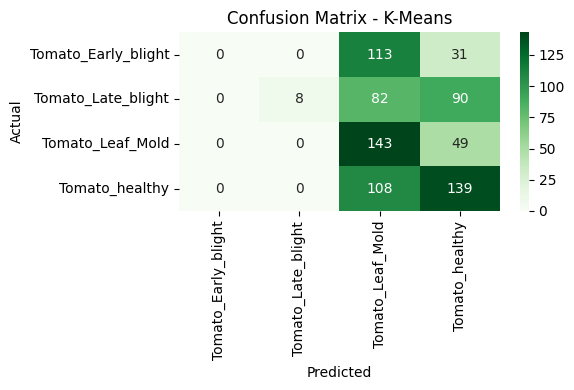

In [9]:
# 7. Evaluate the model
acc = accuracy_score(labels_encoded, y_pred)
print(f"K-Means Clustering Accuracy: {acc * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(labels_encoded, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - K-Means")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [10]:
# 8. Classification Report
print("\nClassification Report:\n")
print(classification_report(labels_encoded, y_pred, target_names=le.classes_))


Classification Report:

                     precision    recall  f1-score   support

Tomato_Early_blight       0.00      0.00      0.00       144
 Tomato_Late_blight       1.00      0.04      0.09       180
   Tomato_Leaf_Mold       0.32      0.74      0.45       192
     Tomato_healthy       0.45      0.56      0.50       247

           accuracy                           0.38       763
          macro avg       0.44      0.34      0.26       763
       weighted avg       0.46      0.38      0.29       763



c:\Users\karan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

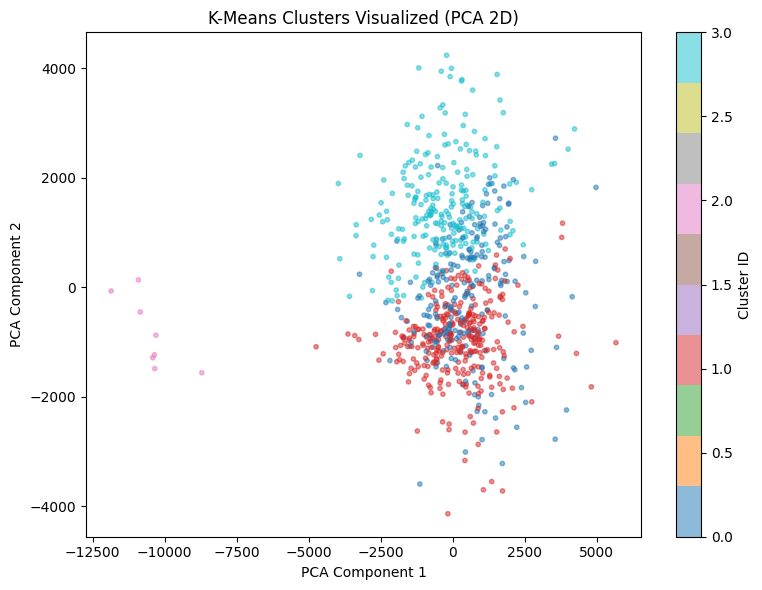

In [11]:
# 9. Visualize clusters in 2D using PCA
# Compress to 2 dimensions just for visualization
pca_2d = PCA(n_components=2, random_state=42)
data_2d = pca_2d.fit_transform(data)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster ID')
plt.title("K-Means Clusters Visualized (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

Predicted Disease Category: Tomato_healthy


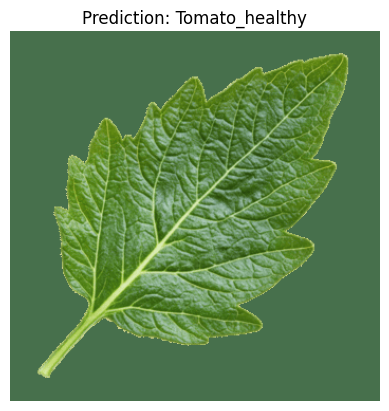

In [15]:
# 10. Predict disease for a new image
def predict_image_class_kmeans(image_path, kmeans_model, pca_model, image_size=(64, 64)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not load image")
    img = cv2.resize(img, image_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_flat = img.flatten().reshape(1, -1)
    img_pca = pca_model.transform(img_flat)        # Reduce dimensions
    cluster = kmeans_model.predict(img_pca)[0]     # Find nearest cluster
    label_id = cluster_to_label[cluster]           # Map cluster to disease
    return le.inverse_transform([label_id])[0]

# Example prediction
new_image_path = r"D:\projects\Disease-Detection-Project\test images\tomato_leaf.png"
try:
    result = predict_image_class_kmeans(new_image_path, kmeans, pca)
    print(f"Predicted Disease Category: {result}")
except Exception as e:
    print("Prediction Error:", e)
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(new_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()